In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from ndcube import NDCube

In [9]:
def plot_vbi_iris(Hbeta_dset, Hbeta_date_obs,
                  Halpha_dset, Halpha_date_obs,
                  hri_dset, hri_date_obs,
                  irissji_dset, irissji_date_obs,
                  target_wcs, target_wcs_rebin,
                  save_dir, figsize=(11,11), ii=20):

    fig = plt.figure(figsize=figsize)

    iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - irissji_date_obs))
    Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - Halpha_date_obs))
    Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[0] - Hbeta_date_obs))

    ax1 = fig.add_subplot(221, projection=target_wcs_rebin)
    im1 = ax1.imshow(hri_dset[0].compute(), cmap="sdoaia171",
            vmin=np.nanpercentile(hri_dset[0,:,:].compute(), 0.1),
            vmax=np.nanpercentile(hri_dset[0,:,:].compute(), 99.9), interpolation="none")
    title1 = ax1.set_title(r"Reproj. EUI/HRI$_{{\rm EUV}}$ 17.4 nm {}".format(hrieuv_date_ear[0].strftime("%Y-%m-%dT%H:%M:%S")))

    ax2 = fig.add_subplot(222, projection=target_wcs_rebin)
    im2 = ax2.imshow(irissji_dset[iris_index_].compute(), cmap="irissji1400",
            vmin=np.nanpercentile(irissji_dset[0,:,:].compute(), 1),
            vmax=np.nanpercentile(irissji_dset[0,:,:].compute(), 99), interpolation="none")
    title2 = ax2.set_title(r"IRIS/SJI 140.0 nm {}".format(irissji_date_obs[iris_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax3 = fig.add_subplot(223, projection=target_wcs)
    im3 = ax3.imshow(Halpha_dset[Halpha_index_].compute(), cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1, stretch=AsinhStretch(0.6)), interpolation="none")
    title3 = ax3.set_title(r"DKIST/VBI-R H$\alpha$ {}".format(Halpha_date_obs[Halpha_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    ax4 = fig.add_subplot(224, projection=target_wcs)
    im4 = ax4.imshow(Hbeta_dset[Hbeta_index_].compute(), cmap="Greys_r",
               norm=ImageNormalize(vmin=0, vmax=1), interpolation="none")
    title4 = ax4.set_title(r"DKIST/VBI-B H$\beta$ {}".format(Hbeta_date_obs[Hbeta_index_].strftime("%Y-%m-%dT%H:%M:%S")))

    for ax_ in (ax1, ax2, ax3, ax4):
        ax_.coords.grid(True, color='white', ls=':', lw=0.8, alpha=0.8)

    for ax_ in (ax1, ax2, ax4):
        ax_.coords[0].axislabels.set_visible(False)
        ax_.coords[1].axislabels.set_visible(False)
    
    ax3.coords[0].set_axislabel("Helioprojective Longitude (Solar-X)")
    ax3.coords[1].set_axislabel("Helioprojective Latitude (Solar-Y)")

    fig.tight_layout()

    iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - irissji_date_obs))
    Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - Halpha_date_obs))
    Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[ii] - Hbeta_date_obs))

    im1.set_data(hri_dset[ii].compute() if hasattr(hri_dset[ii], 'compute') else hri_dset[ii])
    im2.set_data(irissji_dset[iris_index_].compute() if hasattr(irissji_dset[iris_index_], 'compute') else irissji_dset[iris_index_])
    im3.set_data(Halpha_dset[Halpha_index_].compute() if hasattr(Halpha_dset[Halpha_index_], 'compute') else Halpha_dset[Halpha_index_])
    im4.set_data(Hbeta_dset[Hbeta_index_].compute() if hasattr(Hbeta_dset[Hbeta_index_], 'compute') else Hbeta_dset[Hbeta_index_])

In [3]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_Halpha_pr = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

file_hri_pr_dset = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/HRIEUV_pr.hdf5")
hri_pr_set = file_hri_pr_dset["hrieuv_img"]
hri_pr_da = da.from_array(hri_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))

hrieuv_date_ear = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

file_irissji_pr_dset = h5py.File("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/IRISSJI_1400_pr.hdf5")
irissji_pr_set = file_irissji_pr_dset["irissji_1400_img"]
irissji_pr_da = da.from_array(irissji_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
irissji_date_obs = Time(ascii.read("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/IRISSJI_1400_date_obs.txt")["date_obs"])

dkist_vbi_target_header = fits.getheader("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


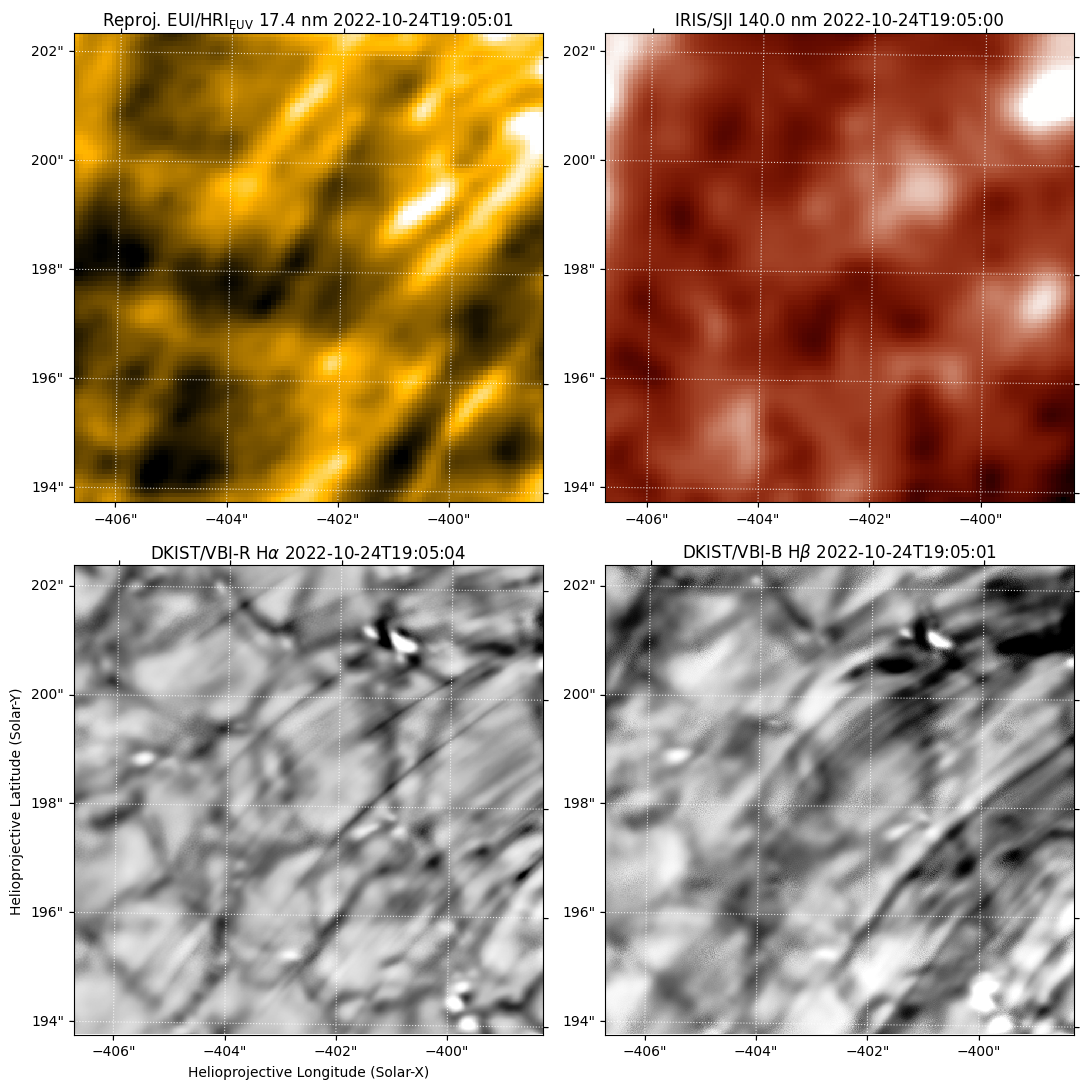

In [12]:
xstart_1 = 600
xend_1 = 1400
ystart_1 = 1400
yend_1 = 2200
plot_vbi_iris(Hbeta_pr_da[:,ystart_1:yend_1, xstart_1:xend_1], Hbeta_date_obs,
                Halpha_pr_da[:,ystart_1:yend_1, xstart_1:xend_1], Halpha_date_obs,
                hri_pr_da[:,ystart_1//8:yend_1//8, xstart_1//8:xend_1//8], hrieuv_date_ear,
                irissji_pr_da[:,ystart_1//8:yend_1//8, xstart_1//8:xend_1//8], irissji_date_obs,
                dkist_vbi_target_cube_crop[ystart_1:yend_1, xstart_1:xend_1].wcs,
                dkist_vbi_target_cube_crop_rebin[ystart_1//8:yend_1//8, xstart_1//8:xend_1//8].wcs,
                save_dir="/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/figs/movie/movie_vbi_iris_4panels_zoomin_1.mp4",
                figsize=(11,11), ii=120)